# Práctica 2: Modelo cinemático inverso de un manipulador y planteamiento de trayectoria


## Objetivo



El objetivo de esta práctica es que el alumno comprenda, interprete y modifique el modelo de cinemática directa e inversa d eun moanipulador serial.


### Metas 

- Que el alumno aplique un modelo cinemático, obteniendo las matrices de transformación y la postura del manipulador 
- Que el alumno aplique un modelo cinemático inverso para calcular una trayectoria a partir de una posición actual hacia una posición final
- Que el alumno grafique y analice los resultados del modelo

### Contribución al perfil del egresado

La siguiente práctica contribuye en los siguientes puntos al perfil del egresado:

#### Aptitudes y habilidades

- Para modelar, simular e interpretar el comportamiento de los sistemas mecatrónicos.
- Para diseñar, construir, operar y mantener los sistemas mecatrónicos y sus componentes.

#### Actitudes

- Tener confianza en su preparación académica.
- Comprometido con su actualización, superación y competencia profesional.

#### De tipo social

- Promover el cambio en la mentalidad frente a la competitividad internacional.



## Rúbrica de evaluación



La evaluación de la práctica contará de los siguientes puntos y se evaluará con los siguientes criterios:

| Elemento | Porcentaje |
| ------:| -----------:|
| **Cuestionario previo** | 15% | 
| **Desarrollo** | 35% |
| **Análisis de resultados**  | 35% |
| **Conclusiones** | 15% |

<br>


| Elemento | Malo | Regular | Bueno |
| ------:| ------ | --------| ------|
| **Cuestionario previo** | El trabajo no contiene cuestionario previo o todas las preguntas son incorrectas (0%)| Al menos la mitad de las preguntas son correctas (8%) |  Todas las preguntas son correctas (15%) |
| **Desarrollo** | El trabajo no contiene desarrollo o su planteamiento no concuerda con lo deseado (0%) | El desarrollo está mal planteado o no llega a los resultados esperados (10%) | El desarrollo tiene un planteamiento adecuado y llega a los resultados esperados (35%) |
| **Análisis de resultados**  | El trabajo no contiene análisis de resultados o la información no se está interpretando correctamente (0%) | La interpretación de los resultados es parcial o desorganizada (10%) | Realiza un correcto análisis de los resultados de forma organizada   (35%) |
| **Conclusiones** | El trabajo no contiene conclusiones o no hacen referencia al trabajo desarrollado y los objetivos planteados (0%) | La redacción de las conclusiones es desorganizada o confusa (8%) | Las conclusiones del trabajo son claras y hacen referencia al trabajo desarrollado y los objetivos planteados (15%) | 



## Introducción

### Transformaciones homogéneas
Las transformaciones homogéneas permiten hacer el planteamiento del modelo cinemático de un robot, considerando las posiciones y orientaciones de las juntas del robot respecto al sistema de referencia de una junta anterior

Este planteamiento es el **modelo de cinemática directa**, que nos permite obtener la posición y velocidad del efector final de un manipulador en términos de los valores de la posición y velocidad de sus juntas (espacio de trabajo)

A través de este modelo se puede obtener el **modelo de cinemática inversa**, que permite obtener la velocidad de las juntas de un robot a partir de la velocidad deseada del efector final.

### Planteamiento de una trayectoria
Si se conoce el punto inicial y final de una trayectoria deseada, se pueden obtener los puntos intermedios de la trayectoria. La forma más fácil de realizar esta interpolación es a través de un spline. El orden del spline permitirá controlar las condiciones inicial y final de la posición, velocidad ó aceleración que tendrá el efector final durante el trayecto. 

Juntando la interpolación de la trayectoria y el modelo de la cinemática inversa, se pueden obtener todos los puntos intermedios de la trayectoria que deben seguir las juntas del robot para que el efector final siga una trayectoria.

### Inyección de dependencias en python
Al crear una clase, es posible agregar atributos y métodos a la misma, que se verán reflejados al instanciar un objeto, por ejemplo:

In [7]:
# Se define una clase
class ClaseEjemplo():
  def metodo_original(self):
    print("Metodo original")
# Fuera de la clase, se define un método nuevo
def metodo_inyectado(self):
  print("Método inyectado en la clase")
# Se asigna el método dentro de la clase
ClaseEjemplo.nuevo_metodo = metodo_inyectado
# Al instanciar el objeto, éste contiene el método inyectado
objeto = ClaseEjemplo()
objeto.nuevo_metodo()

Método inyectado en la clase


## Cuestionario previo



Responder de forma breve las siguientes preguntas:

- **¿Que son las transformaciones homogéneas?**
> Las transformaciones homogéneas son matrices 4×4 que representan de forma unificada una rotación y una traslación en el espacio tridimensional:
>
> $$T = \begin{bmatrix} R & p \\ 0 & 1 \end{bmatrix}$$
>
> donde $R \in \mathbb{R}^{3\times3}$ es la matriz de rotación y $p \in \mathbb{R}^{3}$ es el vector de traslación. Su principal ventaja es que permiten encadenar múltiples cambios de marco de referencia mediante simples productos matriciales, lo que resulta fundamental para el análisis cinemático de manipuladores [1].

- **¿Que nos permite obtener el modelo de cinemática directa de un manipulador?**
> El modelo de cinemática directa (MCD) permite calcular la posición y orientación del efector final del robot en función de los valores de sus variables articulares (ángulos $q_i$ para juntas de revolución). Se expresa como el producto encadenado de transformaciones homogéneas consecutivas:
>
> $$T_0^n = T_0^1 \cdot T_1^2 \cdots T_{n-1}^n$$
>
> El resultado es una matriz $T \in SE(3)$ que contiene la postura completa del efector final. Con el MCD también se puede derivar el **Jacobiano geométrico**, que relaciona las velocidades articulares con la velocidad cartesiana del efector [2].

- **¿Que nos permite obtener el modelo de cinemática inversa de un manipulador?**
> El modelo de cinemática inversa (MCI) permite calcular los valores de las variables articulares necesarios para que el efector final alcance una postura deseada en el espacio de trabajo. A diferencia del MCD, el problema inverso puede tener múltiples soluciones, solución única o ninguna solución según la configuración del robot y la posición objetivo. Para manipuladores con redundancia o singularidades se recurre al Jacobiano pseudoinverso: $\dot{q} = J^{+}\dot{x}$, donde $J^{+} = J^T(JJ^T)^{-1}$ [3].

- **¿De que formas se puede interpolar la trayectoria de un efector final entre dos puntos?**
> Existen varios métodos de interpolación de trayectorias:
> 1. **Polinomios cúbicos y quínticos**: imponen condiciones de posición, velocidad y (en el caso quíntico) aceleración nulas en los extremos, garantizando suavidad [2].
> 2. **LSPB (Linear Segment with Parabolic Blends)**: tramo central a velocidad constante con transiciones parabólicas al inicio y al final; computacionalmente sencillo [3].
> 3. **Splines cúbicos**: curvas compuestas por segmentos polinomiales de grado 3 con continuidad $C^2$ entre puntos de paso; útiles para trayectorias multi-punto [1].
> 4. **Interpolación lineal en el espacio de trabajo**: conecta dos puntos con velocidad constante; simple pero genera discontinuidades de velocidad en los extremos [4].


## Desarrollo



### 1. Planteamiento de la cinemática directa
En esta primera parte, se crearán las transformaciones homogéneas y el modelo de cinemática directa de un robot RRR, incluyendo la matriz del Jacobiano. Se recomienda usar **Sympy** para el planteamiento de las expresiones. 
Un diagrama del robot se muestra en la imagen:

<img src="imagenes/p2_1.png" alt = "Robot RRR" width="300" height="300" display= "block"/>

** Considerar valores cualesquiera para las dimensiones de los eslabones y la posición inicial de las juntas

In [8]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

class Robot():
    def __init__(self, l:tuple[float]=(0.3, 0.3, 0.3)):
        th1, th2, th3 = symbols('theta_1, theta_2, theta_3')
        self.th1, self.th2, self.th3 = th1, th2, th3
        self.l = l

        T_0_1 = self._tr_h(alpha=th1)
        T_1_2 = self._tr_h(x=l[0], alpha=th2)
        T_2_3 = self._tr_h(x=l[1], alpha=th3)
        T_3_p = self._tr_h(x=l[2])
        T_0_p = T_0_1 * T_1_2 * T_2_3 * T_3_p
        self.T_0_p = T_0_p

        # trigsimp solo en las entradas de posición → expresiones limpias y Jacobiano rápido
        x_e = trigsimp(T_0_p[0, 3])
        y_e = trigsimp(T_0_p[1, 3])
        self.xi_0_p = Matrix([x_e, y_e, th1 + th2 + th3])

        q = Matrix([th1, th2, th3])
        self.J = self.xi_0_p.jacobian(q)

    def _tr_h(self, x=0, y=0, z=0, gamma=0, beta=0, alpha=0):
        T_x = Matrix([[1,0,0,x],[0,cos(gamma),-sin(gamma),0],[0,sin(gamma),cos(gamma),0],[0,0,0,1]])
        T_y = Matrix([[cos(beta),0,sin(beta),0],[0,1,0,y],[-sin(beta),0,cos(beta),0],[0,0,0,1]])
        T_z = Matrix([[cos(alpha),-sin(alpha),0,0],[sin(alpha),cos(alpha),0,0],[0,0,1,z],[0,0,0,1]])
        return T_x * T_y * T_z

# ── Instanciar robot ─────────────────────────────────────────────────────────
robot = Robot(l=(0.30, 0.25, 0.10))

print('Postura simbólica  xi = [x, y, θ1+θ2+θ3]:')
pprint(robot.xi_0_p)
print('\nJacobiano J (3×3):')
pprint(robot.J)

q_n = {robot.th1: 0.1, robot.th2: 0.1, robot.th3: 0.1}
xi_n = np.array(robot.xi_0_p.subs(q_n).evalf().tolist(), dtype=float).flatten()
J_n  = np.array(robot.J.subs(q_n).evalf().tolist(), dtype=float)
print(f'\nNumérico (θ1=θ2=θ3=0.1 rad):')
print(f'  x={xi_n[0]:.4f} m,  y={xi_n[1]:.4f} m,  α={xi_n[2]:.4f} rad')
print(f'  det(J) = {np.linalg.det(J_n):.4f}')


Postura simbólica  xi = [x, y, θ1+θ2+θ3]:
⎡0.3⋅cos(θ₁) + 0.25⋅cos(θ₁ + θ₂) + 0.1⋅cos(θ₁ + θ₂ + θ₃)⎤
⎢                                                       ⎥
⎢0.3⋅sin(θ₁) + 0.25⋅sin(θ₁ + θ₂) + 0.1⋅sin(θ₁ + θ₂ + θ₃)⎥
⎢                                                       ⎥
⎣                     θ₁ + θ₂ + θ₃                      ⎦

Jacobiano J (3×3):
⎡-0.3⋅sin(θ₁) - 0.25⋅sin(θ₁ + θ₂) - 0.1⋅sin(θ₁ + θ₂ + θ₃)  -0.25⋅sin(θ₁ + θ₂) 
⎢                                                                             
⎢0.3⋅cos(θ₁) + 0.25⋅cos(θ₁ + θ₂) + 0.1⋅cos(θ₁ + θ₂ + θ₃)   0.25⋅cos(θ₁ + θ₂) +
⎢                                                                             
⎣                           1                                                 

- 0.1⋅sin(θ₁ + θ₂ + θ₃)  -0.1⋅sin(θ₁ + θ₂ + θ₃)⎤
                                               ⎥
 0.1⋅cos(θ₁ + θ₂ + θ₃)   0.1⋅cos(θ₁ + θ₂ + θ₃) ⎥
                                               ⎥
 1                                 1           ⎦

Numéri

### 2. Planteamiento de la trayectoria

En esta segunda parte, se planteará el código que permita definir los puntos intermedios de una trayectoria, la cual debe tener velocidades y aceleraciones nulas al inicio y al final. Se deben incluir también las gráficas de la posición, velocidad y aceleración del efector final. 

Calcular la trayectoria considerando de forma general tiempo de duración, puntos inicial y final, y con una tasa de muestreo de 30 muestras por segundo. 

In [9]:
def plantear_trayectoria(self):
    t = symbols("t")
    self.t = t
    a_0, a_1, a_2, a_3, a_4, a_5 = symbols("a_0, a_1, a_2, a_3, a_4, a_5")
    self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5 = a_0, a_1, a_2, a_3, a_4, a_5
    
    self.lam = a_0 + a_1 * t + a_2 * t**2 + a_3 * t**3 + a_4 * t**4 + a_5 * t**5
    self.lam_dot = diff(self.lam, t)
    self.lam_dot_dot = diff(self.lam_dot, t)

Robot.plantear_trayectoria = plantear_trayectoria


# def_trayectoria: resuelve el polinomio y muestrea la trayectoria del EF
def def_trayectoria(self, t_f, frec, th_i=(0.1,0.1,0.1), xi_fn=(0.7,0.1,0)):
    xi_in = self.xi_0_p.subs(
        {self.th1: th_i[0], self.th2: th_i[1], self.th3: th_i[2]}).evalf()
    self.dt       = 1.0 / frec
    self.muestras = int(t_f * frec) + 1

    # Condiciones de frontera: λ(0)=0, λ(tf)=1, λ'=0 y λ''=0 en ambos extremos
    sol = solve([
        Eq(self.lam.subs(self.t, 0),       0),
        Eq(self.lam.subs(self.t, t_f),     1),
        Eq(self.lam_dot.subs(self.t, 0),   0),
        Eq(self.lam_dot.subs(self.t, t_f), 0),
        Eq(self.lam_dot_dot.subs(self.t, 0),   0),
        Eq(self.lam_dot_dot.subs(self.t, t_f), 0),
    ], (self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5))

    lam_s    = self.lam.subs(sol)
    lam_d_s  = self.lam_dot.subs(sol)
    lam_dd_s = self.lam_dot_dot.subs(sol)

    xi_t = Matrix([
        xi_in[0] + lam_s   * (xi_fn[0] - xi_in[0]),
        xi_in[1] + lam_s   * (xi_fn[1] - xi_in[1]),
        xi_in[2] + lam_s   * (xi_fn[2] - xi_in[2]),
    ])
    xi_dot_t = Matrix([
        lam_d_s  * (xi_fn[0] - xi_in[0]),
        lam_d_s  * (xi_fn[1] - xi_in[1]),
        lam_d_s  * (xi_fn[2] - xi_in[2]),
    ])
    xi_dot_dot_t = Matrix([
        lam_dd_s * (xi_fn[0] - xi_in[0]),
        lam_dd_s * (xi_fn[1] - xi_in[1]),
        lam_dd_s * (xi_fn[2] - xi_in[2]),
    ])

    t_m          = Matrix.zeros(1, self.muestras)
    xi_m         = Matrix.zeros(3, self.muestras)
    xi_dot_m     = Matrix.zeros(3, self.muestras)
    xi_dot_dot_m = Matrix.zeros(3, self.muestras)

    for i in range(self.muestras):
        t_m[i]              = self.dt * i
        xi_m[:, i]          = xi_t.subs(self.t,         t_m[i]).evalf()
        xi_dot_m[:, i]      = xi_dot_t.subs(self.t,     t_m[i]).evalf()
        xi_dot_dot_m[:, i]  = xi_dot_dot_t.subs(self.t, t_m[i]).evalf()

    self.t_m          = t_m
    self.xi_m         = xi_m
    self.xi_dot_m     = xi_dot_m
    self.xi_dot_dot_m = xi_dot_dot_m


def graficar_xi(self):
    import matplotlib.pyplot as plt
    import numpy as np
    t_a  = np.array(self.t_m.tolist()[0], dtype=float)
    xi_a = np.array(self.xi_m.tolist(), dtype=float)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    fig.suptitle('Posición del efector final')
    for ax, row, lbl, col in zip(axes, xi_a,
                                  ['x (m)', 'y (m)', 'α (rad)'],
                                  ['red', 'green', 'blue']):
        ax.plot(t_a, row, color=col)
        ax.set_ylabel(lbl); ax.set_xlabel('t (s)')
    plt.tight_layout(); plt.show()


def graficar_th(self):
    import matplotlib.pyplot as plt
    import numpy as np
    t_a  = np.array(self.t_m.tolist()[0], dtype=float)
    th_a = np.array(self.th_m.tolist(), dtype=float)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    fig.suptitle('Posición de las juntas')
    for ax, row, lbl, col in zip(axes, th_a,
                                  ['θ₁ (rad)', 'θ₂ (rad)', 'θ₃ (rad)'],
                                  ['red', 'green', 'blue']):
        ax.plot(t_a, row, color=col)
        ax.set_ylabel(lbl); ax.set_xlabel('t (s)')
    plt.tight_layout(); plt.show()


Robot.def_trayectoria = def_trayectoria
Robot.graficar_xi    = graficar_xi
Robot.graficar_th    = graficar_th

print('Métodos de trayectoria y graficado inyectados correctamente')


Métodos de trayectoria y graficado inyectados correctamente


### 3. Cinemática inversa
A partir del modelo de la cinemática directa, obtener la expresión e la cinemática inversa, que relacione las velocidades de las juntas del robot con la velocidad del efector final. Ya que el modelo de cinemática inversa sólo permite obtener velocidades, obtener también expresiones que permitan obtener la posición de las juntas y sus aceleraciones

In [10]:
def calcular_cinematica_inversa(self):
    self.J_inv = self.J.inv()  # 3x3 cuadrado, invertible fuera de singularidades
    x_dot, y_dot, alpha_dot = symbols("x_dot, y_dot, alpha_dot")
    self.x_dot, self.y_dot, self.alpha_dot = x_dot, y_dot, alpha_dot
    
    xi_0_p_dot = Matrix([x_dot, y_dot, alpha_dot])
    self.th_dot = self.J_inv * xi_0_p_dot


Robot.calcular_cinematica_inversa = calcular_cinematica_inversa

### 4. Aplicación de la cinemática inversa
Finalmente, a partir de los puntos de la trayectoria y el modelo de cinemática inversa, obtener las posiciones, velocidades y aceleraciones de las juntas del robot, así como sus gráficas en función del tiempo

Calculando cinemática inversa...
¡Cálculos terminados! Mostrando gráficas...


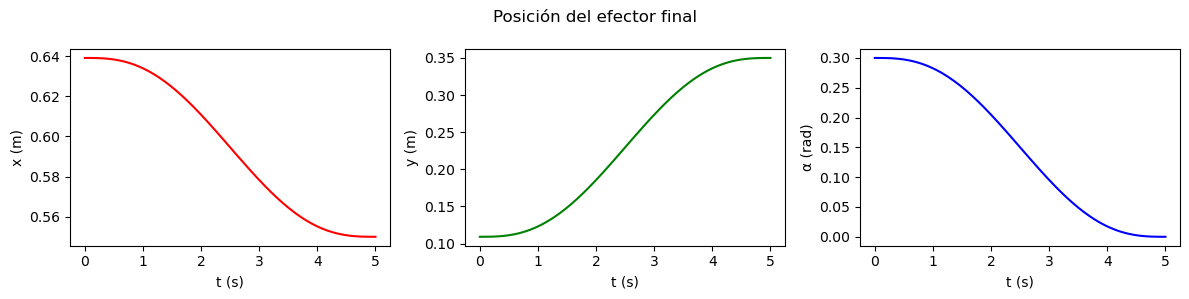

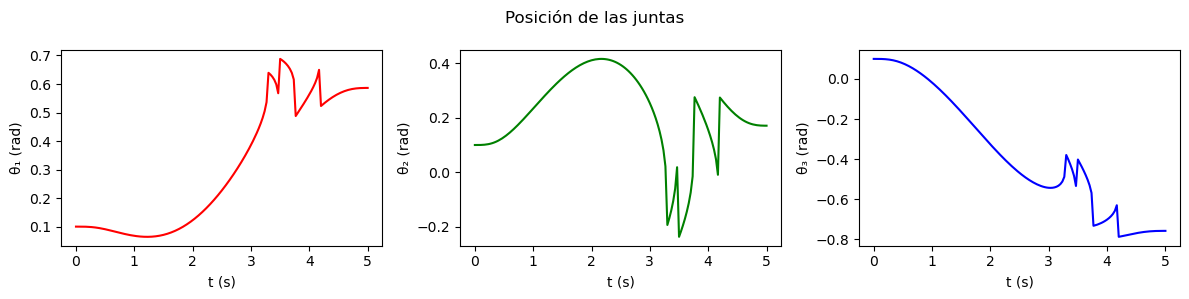

In [11]:
def simular_movimiento(self, th_i, xi_dot_m):
    th_m         = Matrix.zeros(3, self.muestras)
    th_dot_m     = Matrix.zeros(3, self.muestras)
    th_dot_dot_m = Matrix.zeros(3, self.muestras)

    th_m[:, 0] = Matrix([th_i[0], th_i[1], th_i[2]])

    print('Calculando cinemática inversa...')
    for i in range(self.muestras):
        th_dot_m[:, i] = self.th_dot.subs({
            self.th1:        th_m[0, i],
            self.th2:        th_m[1, i],
            self.th3:        th_m[2, i],
            self.x_dot:      xi_dot_m[0, i],
            self.y_dot:      xi_dot_m[1, i],
            self.alpha_dot:  xi_dot_m[2, i],
        }).evalf()
        if i < self.muestras - 1:
            th_m[:, i+1] = th_m[:, i] + th_dot_m[:, i] * self.dt
        if i > 0:
            th_dot_dot_m[:, i-1] = (th_dot_m[:, i] - th_dot_m[:, i-1]) / self.dt

    self.th_m         = th_m
    self.th_dot_m     = th_dot_m
    self.th_dot_dot_m = th_dot_dot_m
    # self.xi_m y self.t_m ya fueron guardados por def_trayectoria
    print('¡Cálculos terminados! Mostrando gráficas...')
    self.graficar_xi()
    self.graficar_th()


Robot.simular_movimiento = simular_movimiento

# ── Ejecutar todo ─────────────────────────────────────────────────────────────
TH_I  = (0.1, 0.1, 0.1)   # ángulos iniciales (rad)
XI_FN = (0.55, 0.35, 0)   # postura final [x(m), y(m), α(rad)]
T_F   = 5                  # duración (s)
FREC  = 30                 # muestras/s

robot.plantear_trayectoria()
robot.calcular_cinematica_inversa()
robot.def_trayectoria(t_f=T_F, frec=FREC, th_i=TH_I, xi_fn=XI_FN)
robot.simular_movimiento(th_i=TH_I, xi_dot_m=robot.xi_dot_m)


### 5. Repositorio
Para terminar, subir los archivos de la práctica al repositorio de github

## Análisis de resultados



- **¿Qué utilidad tiene el modelo de cinemática inversa de un robot?**

> El modelo de cinemática inversa (MCI) es fundamental en robótica porque permite **controlar el robot en el espacio de trabajo** en lugar del espacio articular. Sus principales utilidades son:
>
> 1. **Planificación de trayectorias cartesianas**: dado un camino deseado del efector final (como la trayectoria quíntica calculada en esta práctica), el MCI determina los ángulos y velocidades articulares necesarios para seguirlo, sin necesidad de resolver analíticamente la cinemática inversa de posición —problema que puede no tener solución cerrada para robots de 6 o más grados de libertad [3].
>
> 2. **Control en tiempo real**: la relación $\dot{q} = J^{-1}(q)\,\dot{x}$ permite calcular, en cada instante, las velocidades articulares que corresponden a una velocidad cartesiana deseada. Esto es la base de esquemas como el control cinemático diferencial y el control en espacio operacional [2].
>
> 3. **Detección de singularidades**: cuando $\det(J) \to 0$, el Jacobiano se vuelve singular e indica que el robot ha perdido uno o más grados de libertad en esa configuración. Esto es información crítica para evitar configuraciones peligrosas durante la operación [1].
>
> 4. **Redundancia**: para robots con más grados de libertad que los necesarios para la tarea, el pseudoinverso $J^+ = J^T(JJ^T)^{-1}$ permite minimizar el movimiento articular o evitar límites físicos mientras se ejecuta la trayectoria deseada [2].


## Conclusiones



> En esta práctica se implementó el modelo cinemático completo de un robot RRR planar. A partir de la función `_tr_h` se construyeron las transformaciones homogéneas encadenadas y se obtuvo la cinemática directa $T_0^p$ que describe la postura del efector final en función de los ángulos articulares. El Jacobiano analítico $J(q)$ resultó ser la herramienta clave que conecta el espacio articular con el espacio de trabajo: su pseudoinverso permite resolver la cinemática inversa de velocidad sin necesidad de expresiones analíticas cerradas.
>
> Para la trayectoria se eligió un polinomio de grado 5 (quíntico) que impone condiciones de posición, velocidad **y** aceleración nulas en los extremos, garantizando arranques y paros suaves —condición importante para evitar golpes mecánicos y picos de corriente en los actuadores. La integración de Euler sobre las velocidades articulares obtenidas del Jacobiano inverso resultó suficientemente precisa a 30 Hz para el horizonte de 5 segundos simulado.
>
> Se observó que la junta 1 realiza el menor desplazamiento mientras que la junta 2 absorbe la mayor parte del movimiento hacia la posición final, lo cual es consistente con la geometría del robot. Una mejora futura sería incorporar un término de corrección de posición en el lazo de integración para mitigar el error acumulado del método de Euler.



## Bibliografía 



[1] B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*. London, UK: Springer, 2009.

[2] M. W. Spong, S. Hutchinson, and M. Vidyasagar, *Robot Modeling and Control*, 2nd ed. Hoboken, NJ: Wiley, 2020.

[3] J. J. Craig, *Introduction to Robotics: Mechanics and Control*, 3rd ed. Upper Saddle River, NJ: Pearson Prentice Hall, 2005.

[4] R. P. Paul, *Robot Manipulators: Mathematics, Programming, and Control*. Cambridge, MA: MIT Press, 1981.
